<h1>Imports</h1>

In [164]:

#alpaca api imports
from alpaca.data import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

# Env file imports
from dotenv import load_dotenv

# misc imports
from datetime import datetime
import os
import mplfinance as mpf




<h1>Loading Api Keys</h1>

In [165]:
load_dotenv()

api_key = os.environ.get('ALPACA_API_KEY')
secret_key = os.environ.get('ALPACA_SECRET_KEY')



<h1>Setting up the client</h1>

In [166]:
stock_client = StockHistoricalDataClient(api_key, secret_key)

<h1>Setting up the request function</h1>

In [167]:
def get_stock_data(symbol, timeframe, start_time, end_time):
    """
    Fetches historical stock data for a given symbol, timeframe, and date range.
    Args:        symbol (str): The stock symbol to fetch data for (e.g., "AAPL").
        timeframe (TimeFrame): The timeframe for the data (e.g., TimeFrame.Day).
        start_time (datetime): The start date for the data (e.g., datetime(2023, 1, 1)).
        end_time (datetime): The end date for the data (e.g., datetime(2026, 12, 31)).
    
    """

    request_params = StockBarsRequest(symbol_or_symbols = symbol,
                                        timeframe = timeframe,
                                        start = start_time,
                                        end = end_time)
    
    bars = stock_client.get_stock_bars(request_params)
    
    return bars

<h1>Getting the data and resetting the indexes<h1>

In [168]:
bars = get_stock_data("AAPL", TimeFrame.Day, datetime(2026, 5, 1), datetime(2026, 5, 20))


df = bars.df

bars_df = df.reset_index()  
bars_df = bars_df.set_index('timestamp')
bars_df.head()


,symbol,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,,
2026-05-01 04:00:00+00:00,AAPL,278.855,287.22,278.3700,280.14,80105508.0,1301741.0,282.456884
2026-05-04 04:00:00+00:00,AAPL,279.655,280.63,274.8601,276.83,46845300.0,768306.0,276.916261
2026-05-05 04:00:00+00:00,AAPL,276.925,284.57,276.5010,284.18,49478504.0,779580.0,282.316227
2026-05-06 04:00:00+00:00,AAPL,281.915,288.03,281.0700,287.51,58505958.0,839684.0,286.248980
2026-05-07 04:00:00+00:00,AAPL,289.270,292.13,285.7800,287.44,45390735.0,776365.0,288.895050


<h1>Plotting the data for confirmation</h1>

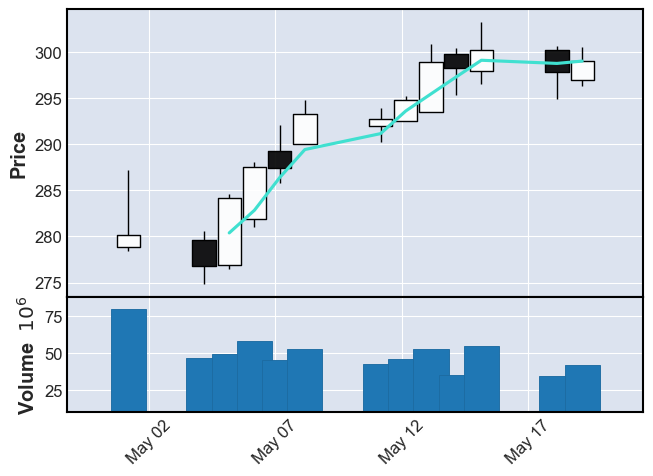

In [ ]:


mpf.plot(bars_df, type='candle',show_nontrading=True, xrotation=45, volume=True)
